 # Uttarakhand Forest Fire Risk Prediction — Data Collection Pipeline

 Builds the weekly time-series dataset (weather + vegetation + terrain + fire labels)

 used to train the CNN-LSTM early-warning model.

In [ ]:
# =====================================================================
# CONFIG — change these to match your own machine before running
# =====================================================================
import os

BASE_DIR = os.environ.get("FFP_BASE_DIR", r"C:\Users\khush\ForestFireProject")  #change it according to your base directory
GEE_PROJECT = os.environ.get("FFP_GEE_PROJECT", "forest-fire-prediction-505318")
DRIVE_FOLDER = "ForestFireProject"  # Google Drive folder GEE exports land in

GIS_DATA = os.path.join(BASE_DIR, "gis_data")
RAW_DIR = os.path.join(GIS_DATA, "raw")
EXPORTS_DIR = os.path.join(GIS_DATA, "gee_exports")
WEATHER_DIR = os.path.join(EXPORTS_DIR, "weekly_weather_2km")
VEG_DIR = os.path.join(EXPORTS_DIR, "monthly_vegetation")
PROCESSED_DIR = os.path.join(GIS_DATA, "processed")
OUTPUTS_DIR = os.path.join(GIS_DATA, "outputs")

UTTARAKHAND_SHAPEFILE = os.path.join(RAW_DIR, "uttarakhand_boundary.shp")
FIRMS_CSV_PATH = os.path.join(RAW_DIR, "fire_data_uttarakhand_2015_2024.csv")
LANDCOVER_TIF = os.path.join(EXPORTS_DIR, "uttarakhand_landcover.tif")
TOPO_TIF = os.path.join(EXPORTS_DIR, "uttarakhand_topography.tif")

START_DATE = "2015-01-01"
END_DATE = "2024-12-31"

WEATHER_BANDS = [
    "temperature_2m", "temperature_2m_max", "dewpoint_temperature_2m",
    "total_precipitation_sum", "u_component_of_wind_10m",
    "v_component_of_wind_10m", "surface_pressure",
    "volumetric_soil_water_layer_1",
]
TOPO_BAND_NAMES = ["elevation", "slope", "aspect"]

# Time-series design (finalized before building the dataset):
#   - weekly resolution (daily was too heavy and vegetation has cloud-cover gaps)
#   - 4-week lookback window
#   - predict 1 week ahead
#   - 2km grid (1km made the CSV blow up to 13GB, so we dropped to 2km)
LOOKBACK = 4


In [ ]:
# =====================================================================
# STEP 1a: Load the Uttarakhand boundary (always needed — local file)
# This is all that's required for everything from here on, since every
# later step reads already-exported .tif/.csv files from disk rather
# than calling Earth Engine live.
# =====================================================================
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
 
uttarakhand_gdf = gpd.read_file(UTTARAKHAND_SHAPEFILE)
print("Boundary loaded:", uttarakhand_gdf.shape)
 
# %%
# =====================================================================
# STEP 1b: Connect to Earth Engine (OPTIONAL)
# Only needed if you plan to re-run one of the commented-out export
# cells further down (e.g. to export new data or re-run with different
# settings). If you're just processing the already-exported files,
# skip this cell entirely — you don't need Earth Engine access for
# that, just the downloaded .tif/.csv files on disk.
# =====================================================================
import ee
import geemap
 
ee.Initialize(project=GEE_PROJECT)
uttarakhand_ee = geemap.geopandas_to_ee(uttarakhand_gdf)
 
# Sanity check — actual Uttarakhand area is ~53,483 sq km
area_sqkm = uttarakhand_ee.geometry().area().divide(1e6).getInfo()
print(f"Setup complete. Uttarakhand area: {area_sqkm:.2f} sq km")
 


Boundary loaded: (1, 10)
Setup complete. Uttarakhand area: 53867.66 sq km


In [ ]:
# ee.Authenticate()  # only needed once per machine, and only if using STEP 1b


FIRMS data shape: (254622, 15)
FIRMS columns: ['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_t31', 'frp', 'daynight', 'type']
Total fire points in Uttarakhand (2015-2024): 150121


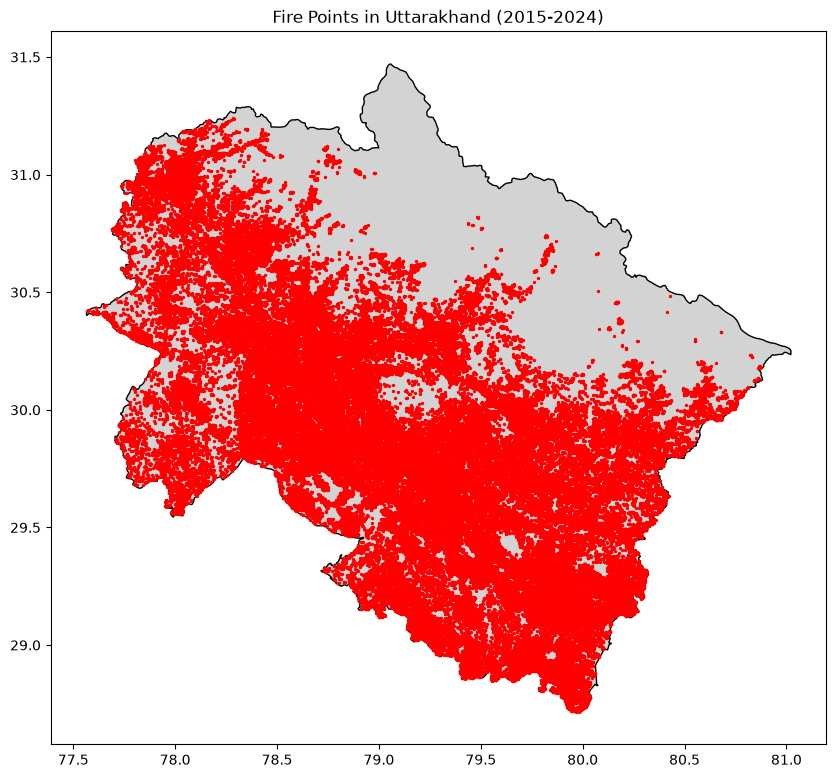

In [9]:
# =====================================================================
# STEP 2: Fire occurrence data (FIRMS) — this becomes our label
# =====================================================================
fire_data = pd.read_csv(FIRMS_CSV_PATH)
print("FIRMS data shape:", fire_data.shape)
print("FIRMS columns:", fire_data.columns.tolist())

fire_data["acq_date"] = pd.to_datetime(fire_data["acq_date"])
fire_data = fire_data[
    (fire_data["acq_date"] >= START_DATE) & (fire_data["acq_date"] <= END_DATE)
]

fire_gdf = gpd.GeoDataFrame(
    fire_data,
    geometry=gpd.points_from_xy(fire_data.longitude, fire_data.latitude),
    crs="EPSG:4326",
)
fire_uttarakhand = gpd.clip(fire_gdf, uttarakhand_gdf)
print("Total fire points in Uttarakhand (2015-2024):", fire_uttarakhand.shape[0])

fig, ax = plt.subplots(figsize=(10, 10))
uttarakhand_gdf.plot(ax=ax, color="lightgray", edgecolor="black")
fire_uttarakhand.plot(ax=ax, color="red", markersize=2)
plt.title("Fire Points in Uttarakhand (2015-2024)")
plt.savefig(os.path.join(OUTPUTS_DIR, "fire_points_map.png"), dpi=150)
plt.show()

fire_uttarakhand.to_csv(
    os.path.join(PROCESSED_DIR, "fire_uttarakhand_clipped.csv"), index=False
)


In [10]:
# =====================================================================
# STEP 3: Baseline exports — vegetation (NDVI/NDMI), weather, and
# topography, exported once as full-period composites for the static
# baseline model. Already run and downloaded — left commented so
# re-running the notebook doesn't kick off duplicate GEE exports.
# =====================================================================

# --- Vegetation indices (Sentinel-2) ---
# sentinel = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
#     .filterBounds(uttarakhand_ee) \
#     .filterDate('2015-06-01', END_DATE) \
#     .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
#
# def add_vegetation_indices(image):
#     ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
#     ndmi = image.normalizedDifference(['B8', 'B11']).rename('NDMI')
#     return image.addBands([ndvi, ndmi])
#
# sentinel_with_indices = sentinel.map(add_vegetation_indices)
# veg_composite = sentinel_with_indices.select(['NDVI', 'NDMI']).median().clip(uttarakhand_ee)
#
# ee.batch.Export.image.toDrive(
#     image=veg_composite, description='Uttarakhand_Vegetation_2015_2024',
#     folder=DRIVE_FOLDER, fileNamePrefix='uttarakhand_ndvi_ndmi_composite',
#     region=uttarakhand_ee.geometry(), scale=30, maxPixels=1e13
# ).start()

# --- Weather (ERA5) ---
# era5 = ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR') \
#     .filterBounds(uttarakhand_ee).filterDate(START_DATE, END_DATE).select(WEATHER_BANDS)
# weather_composite = era5.mean().clip(uttarakhand_ee)
#
# ee.batch.Export.image.toDrive(
#     image=weather_composite, description='Uttarakhand_Weather_Mean_2015_2024',
#     folder=DRIVE_FOLDER, fileNamePrefix='uttarakhand_weather_mean',
#     region=uttarakhand_ee.geometry(), scale=1000, maxPixels=1e13
# ).start()

# --- Topography (SRTM) ---
# elevation = ee.Image('USGS/SRTMGL1_003').clip(uttarakhand_ee)
# slope = ee.Terrain.slope(elevation)
# aspect = ee.Terrain.aspect(elevation)
# topo_combined = elevation.toFloat().rename('elevation') \
#     .addBands(slope.toFloat().rename('slope')) \
#     .addBands(aspect.toFloat().rename('aspect'))
#
# ee.batch.Export.image.toDrive(
#     image=topo_combined, description='Uttarakhand_Topography',
#     folder=DRIVE_FOLDER, fileNamePrefix='uttarakhand_topography',
#     region=uttarakhand_ee.geometry(), scale=30, maxPixels=1e13
# ).start()


In [11]:
# Verify the downloaded baseline exports
import rasterio

for f in [
    "uttarakhand_ndvi_ndmi_composite.tif",
    "uttarakhand_weather_mean.tif",
    "uttarakhand_topography.tif",
]:
    path = os.path.join(EXPORTS_DIR, f)
    with rasterio.open(path) as src:
        print(f"{f}: {src.count} bands, shape {src.shape}, CRS {src.crs}")


uttarakhand_ndvi_ndmi_composite.tif: 2 bands, shape (10230, 12831), CRS EPSG:4326
uttarakhand_weather_mean.tif: 8 bands, shape (308, 386), CRS EPSG:4326
uttarakhand_topography.tif: 3 bands, shape (10230, 12832), CRS EPSG:4326


In [12]:
# =====================================================================
# STEP 4: Resample all three baseline rasters onto a common grid
# (using the weather raster as the reference grid) and build the
# static grid-features dataset for the baseline RF/XGBoost model.
# =====================================================================
from rasterio.warp import reproject, Resampling
from rasterio.features import rasterize
import numpy as np

VEG_TIF = os.path.join(EXPORTS_DIR, "uttarakhand_ndvi_ndmi_composite.tif")
WEATHER_TIF = os.path.join(EXPORTS_DIR, "uttarakhand_weather_mean.tif")
VEG_BAND_NAMES = ["NDVI", "NDMI"]

with rasterio.open(WEATHER_TIF) as ref:
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_shape = (ref.height, ref.width)

print(f"Reference grid shape: {ref_shape}")


def resample_to_reference(src_path, band_names, resampling_method=Resampling.bilinear):
    """Reproject each band of src_path onto the reference grid, filling
    out-of-bounds areas with NaN instead of leaving uninitialized memory."""
    result = {}
    with rasterio.open(src_path) as src:
        for i, band_name in enumerate(band_names, start=1):
            src_band = src.read(i)
            dst_array = np.full(ref_shape, np.nan, dtype=np.float32)
            reproject(
                source=src_band,
                destination=dst_array,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=ref_transform,
                dst_crs=ref_crs,
                resampling=resampling_method,
                src_nodata=src.nodata,
                dst_nodata=np.nan,
            )
            result[band_name] = dst_array
    return result


veg_arrays = resample_to_reference(VEG_TIF, VEG_BAND_NAMES)
weather_arrays = resample_to_reference(WEATHER_TIF, WEATHER_BANDS)
topo_arrays = resample_to_reference(TOPO_TIF, TOPO_BAND_NAMES)
print("Resampling done")


Reference grid shape: (308, 386)
Resampling done


In [13]:
# Rasterize fire points onto the same grid → binary fire_occurred label
fire_df = pd.read_csv(os.path.join(PROCESSED_DIR, "fire_uttarakhand_clipped.csv"))

fire_shapes = [(geom, 1) for geom in gpd.points_from_xy(fire_df.longitude, fire_df.latitude)]
fire_grid = rasterize(
    shapes=fire_shapes, out_shape=ref_shape, transform=ref_transform, fill=0, dtype="uint8"
)
print("Fire label grid built. Total fire cells:", fire_grid.sum())


Fire label grid built. Total fire cells: 31849


In [14]:
# Flatten everything into one dataframe: one row per grid cell
rows, cols = ref_shape
row_idx, col_idx = np.meshgrid(np.arange(rows), np.arange(cols), indexing="ij")
xs, ys = rasterio.transform.xy(ref_transform, row_idx.ravel(), col_idx.ravel())

data = {"longitude": xs, "latitude": ys}
for band_name, arr in veg_arrays.items():
    data[band_name] = arr.ravel()
for band_name, arr in weather_arrays.items():
    data[band_name] = arr.ravel()
for band_name, arr in topo_arrays.items():
    data[band_name] = arr.ravel()
data["fire_occurred"] = fire_grid.ravel()

final_df = pd.DataFrame(data)
print("final_df shape:", final_df.shape)

# Drop cells outside the state boundary (NaN) and any bad elevation pixels
final_df = final_df.dropna(subset=VEG_BAND_NAMES + WEATHER_BANDS + TOPO_BAND_NAMES)
final_df = final_df[final_df["elevation"] > 0]

print("Final shape after cleaning:", final_df.shape)
print(final_df["fire_occurred"].value_counts())
print(final_df["fire_occurred"].value_counts(normalize=True) * 100)

final_df.to_csv(os.path.join(PROCESSED_DIR, "uttarakhand_grid_features.csv"), index=False)
print("Saved static grid-features CSV")


final_df shape: (118888, 16)
Final shape after cleaning: (60434, 16)
fire_occurred
1    30789
0    29645
Name: count, dtype: int64
fire_occurred
1    50.946487
0    49.053513
Name: proportion, dtype: float64
Saved static grid-features CSV


In [15]:
# Sanity check against the raw fire data
print("Total fire records (raw):", len(fire_df))
print("Unique fire locations:", fire_df[["latitude", "longitude"]].drop_duplicates().shape[0])
print("Total valid pixels (final_df):", len(final_df))
print("Total fire=1 cells in full grid:", fire_grid.sum())


Total fire records (raw): 150121
Unique fire locations: 150121
Total valid pixels (final_df): 60434
Total fire=1 cells in full grid: 31849


 ## Time-series dataset for the CNN-LSTM model

 Everything below builds the temporal dataset: for each grid cell, the past

 4 weeks of weather + vegetation → next week's fire risk (0/1). Weather is

 weekly (ERA5, 2km), vegetation is monthly (Sentinel-2 NDVI/NDMI, cloud-cover

 gaps make weekly impractical, so it's forward-filled to weekly), and

 topography is static and reused from the baseline export.

In [16]:
# =====================================================================
# STEP 5: Weekly weather export (2km, year-by-year). Already run and
# downloaded — kept commented to avoid re-triggering GEE exports.
# =====================================================================

# era5 = ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR') \
#     .filterBounds(uttarakhand_ee).select(WEATHER_BANDS)
#
# def weekly_mean(week_start):
#     week_start = ee.Date(week_start)
#     week_end = week_start.advance(1, 'week')
#     weekly_img = era5.filterDate(week_start, week_end).mean()
#     band_names = weekly_img.bandNames().map(
#         lambda b: ee.String(b).cat('_').cat(week_start.format('YYYY_MM_dd'))
#     )
#     return weekly_img.rename(band_names)
#
# def export_year_2km(year):
#     start = ee.Date.fromYMD(year, 1, 1)
#     end = ee.Date.fromYMD(year + 1, 1, 1)
#     n_weeks = end.difference(start, 'week').floor()
#     week_starts = ee.List.sequence(0, n_weeks.subtract(1)).map(lambda n: start.advance(n, 'week'))
#     weekly_stack = ee.ImageCollection(week_starts.map(weekly_mean)).toBands().clip(uttarakhand_ee).toFloat()
#
#     task = ee.batch.Export.image.toDrive(
#         image=weekly_stack, description=f'Uttarakhand_Weekly_Weather_2km_{year}',
#         folder=DRIVE_FOLDER, fileNamePrefix=f'uttarakhand_weekly_weather_2km_{year}',
#         region=uttarakhand_ee.geometry(), scale=2000, maxPixels=1e13
#     )
#     task.start()
#     return task
#
# tasks_2km = {year: export_year_2km(year) for year in range(2015, 2025)}


In [17]:
# Verify the downloaded weekly weather exports
for year in range(2015, 2025):
    path = os.path.join(WEATHER_DIR, f"uttarakhand_weekly_weather_2km_{year}.tif")
    with rasterio.open(path) as src:
        print(f"{year}: {src.count} bands, shape {src.shape}")


2015: 416 bands, shape (154, 193)
2016: 416 bands, shape (154, 193)
2017: 416 bands, shape (154, 193)
2018: 416 bands, shape (154, 193)
2019: 416 bands, shape (154, 193)
2020: 416 bands, shape (154, 193)
2021: 416 bands, shape (154, 193)
2022: 416 bands, shape (154, 193)
2023: 416 bands, shape (154, 193)
2024: 416 bands, shape (154, 193)


In [18]:
# =====================================================================
# STEP 6: Switch the reference grid to the 2km time-series grid
# Everything above (the baseline dataset) used the 1km weather-mean
# raster as its reference grid. Everything below — land cover, forward
# -filled vegetation, topography, and the final time-series rows — must
# be resampled onto the 2km weekly weather grid instead, so all layers
# line up pixel-for-pixel. Re-running this before land cover matters:
# resampling land cover onto the old 1km grid here would silently
# produce a land_cover column that's misaligned with everything else.
# =====================================================================
with rasterio.open(os.path.join(WEATHER_DIR, "uttarakhand_weekly_weather_2km_2015.tif")) as ref:
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_shape = (ref.height, ref.width)

print(f"Switched to 2km reference grid: {ref_shape}")


Switched to 2km reference grid: (154, 193)


In [19]:
# =====================================================================
# STEP 7: Land cover export (ESA WorldCover, static, one-time).
# Already run and downloaded — kept commented.
# =====================================================================

# landcover = ee.ImageCollection('ESA/WorldCover/v200').first().select('Map').clip(uttarakhand_ee)
# # Classes: 10=Tree cover, 20=Shrubland, 30=Grassland, 40=Cropland,
# # 50=Built-up, 60=Bare/sparse veg, 70=Snow/ice, 80=Water, 90=Wetland,
# # 95=Mangroves, 100=Moss/lichen
#
# ee.batch.Export.image.toDrive(
#     image=landcover.toFloat(), description='Uttarakhand_LandCover',
#     folder=DRIVE_FOLDER, fileNamePrefix='uttarakhand_landcover',
#     region=uttarakhand_ee.geometry(), scale=2000, maxPixels=1e13
# ).start()


In [20]:
# Resample land cover onto the reference grid (nearest-neighbor since it's categorical)
with rasterio.open(LANDCOVER_TIF) as src:
    src_band = src.read(1)
    landcover_arr = np.full(ref_shape, np.nan, dtype=np.float32)
    reproject(
        source=src_band,
        destination=landcover_arr,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        resampling=Resampling.nearest,
        src_nodata=src.nodata,
        dst_nodata=np.nan,
    )
print("Land cover resampled. Unique values:", np.unique(landcover_arr[~np.isnan(landcover_arr)]))


Land cover resampled. Unique values: [ 10.  20.  30.  40.  50.  60.  70.  80.  90. 100.]


In [ ]:
# =====================================================================
# STEP 8: Monthly NDVI/NDMI export (year-by-year, 250m scale). Already
# run and downloaded — kept commented.
# =====================================================================

# sentinel = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
#     .filterBounds(uttarakhand_ee).filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
#
# def add_vegetation_indices(image):
#     ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
#     ndmi = image.normalizedDifference(['B8', 'B11']).rename('NDMI')
#     return image.addBands([ndvi, ndmi])
#
# sentinel_with_indices = sentinel.map(add_vegetation_indices)
#
# def monthly_composite(month_start):
#     month_start = ee.Date(month_start)
#     month_end = month_start.advance(1, 'month')
#     monthly_img = sentinel_with_indices.filterDate(month_start, month_end).select(['NDVI', 'NDMI']).median()
#     band_names = monthly_img.bandNames().map(lambda b: ee.String(b).cat('_').cat(month_start.format('YYYY_MM')))
#     return monthly_img.rename(band_names)
#
# def export_vegetation_year(year):
#     start = ee.Date.fromYMD(year, 1, 1)
#     end = ee.Date.fromYMD(year + 1, 1, 1)
#     n_months = end.difference(start, 'month').floor()
#     month_starts = ee.List.sequence(0, n_months.subtract(1)).map(lambda n: start.advance(n, 'month'))
#     monthly_stack = ee.ImageCollection(month_starts.map(monthly_composite)).toBands().clip(uttarakhand_ee).toFloat()
#
#     task = ee.batch.Export.image.toDrive(
#         image=monthly_stack, description=f'Uttarakhand_Monthly_Vegetation_{year}',
#         folder=DRIVE_FOLDER, fileNamePrefix=f'uttarakhand_monthly_vegetation_{year}',
#         region=uttarakhand_ee.geometry(), scale=250, maxPixels=1e13   # here scale is taken 250 instead of 30 (not taken because it had resulted in exceed in gee non-comercial quota)
#     )
#     task.start()
#     return task
#
# veg_tasks = {year: export_vegetation_year(year) for year in range(2015, 2025)}


In [22]:
# Verify the downloaded monthly vegetation exports
for f in sorted(os.listdir(VEG_DIR)):
    if f.endswith(".tif"):
        path = os.path.join(VEG_DIR, f)
        size_mb = os.path.getsize(path) / (1024 * 1024)
        with rasterio.open(path) as src:
            print(f"{f}: {src.count} bands, {size_mb:.1f} MB")


uttarakhand_monthly_vegetation_2015.tif: 4 bands, 8.2 MB
uttarakhand_monthly_vegetation_2016.tif: 20 bands, 61.1 MB
uttarakhand_monthly_vegetation_2017.tif: 18 bands, 52.2 MB
uttarakhand_monthly_vegetation_2018.tif: 20 bands, 72.4 MB
uttarakhand_monthly_vegetation_2019.tif: 22 bands, 78.2 MB
uttarakhand_monthly_vegetation_2020.tif: 24 bands, 88.9 MB
uttarakhand_monthly_vegetation_2021.tif: 22 bands, 84.2 MB
uttarakhand_monthly_vegetation_2022.tif: 22 bands, 86.7 MB
uttarakhand_monthly_vegetation_2023.tif: 22 bands, 89.5 MB
uttarakhand_monthly_vegetation_2024.tif: 24 bands, 96.8 MB


In [23]:
# =====================================================================
# STEP 9: Forward-fill missing vegetation months
# Monsoon cloud cover leaves gaps in some months (and 2015 only has
# Oct-Nov since Sentinel-2 launched in June 2015), so each pixel's
# NDVI/NDMI time series is forward-filled from the last valid reading.
# =====================================================================
import re

records = []  # (year, month, variable, array)

for year in range(2015, 2025):
    path = os.path.join(VEG_DIR, f"uttarakhand_monthly_vegetation_{year}.tif")
    with rasterio.open(path) as src:
        for i, desc in enumerate(src.descriptions, start=1):
            match = re.match(r"\d+_(NDVI|NDMI)_(\d{4})_(\d{2})", desc)
            if not match:
                continue
            var, yr, month = match.groups()
            src_band = src.read(i)
            dst_array = np.full(ref_shape, np.nan, dtype=np.float32)
            reproject(
                source=src_band,
                destination=dst_array,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=ref_transform,
                dst_crs=ref_crs,
                resampling=Resampling.bilinear,
                src_nodata=src.nodata,
                dst_nodata=np.nan,
            )
            records.append({"year": int(yr), "month": int(month), "variable": var, "array": dst_array})

print(f"Total available (year, month, variable) combos: {len(records)}")


Total available (year, month, variable) combos: 198


In [24]:
all_periods = pd.period_range("2015-01", "2024-12", freq="M")
data_dict = {(r["year"], r["month"], r["variable"]): r["array"] for r in records}

filled_data = {}  # {(year, month, var): forward-filled array}

for var in ["NDVI", "NDMI"]:
    last_valid = np.full(ref_shape, np.nan, dtype=np.float32)
    for period in all_periods:
        year, month = period.year, period.month
        key = (year, month, var)
        if key in data_dict:
            current = data_dict[key]
            filled = np.where(~np.isnan(current), current, last_valid)
        else:
            filled = last_valid.copy()  # whole month missing — carry the last value forward
        filled_data[(year, month, var)] = filled
        valid_mask = ~np.isnan(filled)
        last_valid = np.where(valid_mask, filled, last_valid)

print("Forward-fill complete for all months")


Forward-fill complete for all months


In [25]:
# =====================================================================
# STEP 10: Bin fire records into weeks and rasterize each week
# =====================================================================
fire_df = pd.read_csv(os.path.join(PROCESSED_DIR, "fire_uttarakhand_clipped.csv"))
fire_df["acq_date"] = pd.to_datetime(fire_df["acq_date"])


def get_week_start(date):
    year_start = pd.Timestamp(year=date.year, month=1, day=1)
    days_since = (date - year_start).days
    week_num = days_since // 7
    return year_start + pd.Timedelta(weeks=week_num)


fire_df["week_start"] = fire_df["acq_date"].apply(get_week_start)

fire_week_grids = {}
for week_start, group in fire_df.groupby("week_start"):
    shapes = [(geom, 1) for geom in gpd.points_from_xy(group.longitude, group.latitude)]
    grid = rasterize(shapes=shapes, out_shape=ref_shape, transform=ref_transform, fill=0, dtype="uint8")
    fire_week_grids[week_start] = grid

print(f"Total weeks with at least one fire: {len(fire_week_grids)}")


Total weeks with at least one fire: 438


In [26]:
# =====================================================================
# STEP 11: Parse all weekly weather rasters (fast path — read each
# file once instead of reprojecting band by band)
# =====================================================================
weather_week_data = {}

for year in range(2015, 2025):
    path = os.path.join(WEATHER_DIR, f"uttarakhand_weekly_weather_2km_{year}.tif")
    with rasterio.open(path) as src:
        all_bands = src.read()
        for i, desc in enumerate(src.descriptions):
            match = re.match(r"\d+_([a-z_0-9]+)_(\d{4})_(\d{2})_(\d{2})", desc)
            if not match:
                continue
            var, yr, mo, day = match.groups()
            week_start = pd.Timestamp(year=int(yr), month=int(mo), day=int(day))
            weather_week_data.setdefault(week_start, {})[var] = all_bands[i]
    print(f"{year} done")

print(f"Total weeks with weather data: {len(weather_week_data)}")


2015 done
2016 done
2017 done
2018 done
2019 done
2020 done
2021 done
2022 done
2023 done
2024 done
Total weeks with weather data: 520


In [27]:
# Load topography (static, one-time resample)
topo_arrays = {}
with rasterio.open(TOPO_TIF) as src:
    for i, name in enumerate(["elevation", "slope", "aspect"], start=1):
        src_band = src.read(i)
        dst_array = np.full(ref_shape, np.nan, dtype=np.float32)
        reproject(
            source=src_band,
            destination=dst_array,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.bilinear,
            src_nodata=src.nodata,
            dst_nodata=np.nan,
        )
        topo_arrays[name] = dst_array


In [28]:
# Sort weeks and restrict to valid land pixels (elevation must not be NaN)
all_weeks = sorted(weather_week_data.keys())
print(f"Total weeks available: {len(all_weeks)}")

valid_mask = ~np.isnan(topo_arrays["elevation"])
valid_rows, valid_cols = np.where(valid_mask)
print(f"Total valid land pixels: {len(valid_rows)}")

xs, ys = rasterio.transform.xy(ref_transform, valid_rows, valid_cols)


Total weeks available: 520
Total valid land pixels: 14674


In [29]:
# =====================================================================
# STEP 12: Build the final time-series dataset
# For each week (once we have at least LOOKBACK weeks of history):
# past LOOKBACK weeks of weather + current month's vegetation + static
# topography + land cover → next week's fire label. Written straight
# to disk in weekly chunks since the full dataset doesn't fit in memory.
# =====================================================================
OUTPUT_PATH = os.path.join(PROCESSED_DIR, "uttarakhand_timeseries_features_2km.csv")

if os.path.exists(OUTPUT_PATH):
    os.remove(OUTPUT_PATH)

first_write = True

for t in range(LOOKBACK, len(all_weeks) - 1):  # -1 because we need next week's label
    current_week = all_weeks[t]
    next_week = all_weeks[t + 1]

    fire_label_grid = fire_week_grids.get(next_week, np.zeros(ref_shape, dtype="uint8"))

    veg_year, veg_month = current_week.year, current_week.month
    ndvi_arr = filled_data.get((veg_year, veg_month, "NDVI"), np.full(ref_shape, np.nan))
    ndmi_arr = filled_data.get((veg_year, veg_month, "NDMI"), np.full(ref_shape, np.nan))

    row_data = {"longitude": xs, "latitude": ys, "week_start": current_week}

    for lag in range(LOOKBACK):
        week_t = all_weeks[t - lag]
        week_data = weather_week_data.get(week_t, {})
        for var in WEATHER_BANDS:
            arr = week_data.get(var, np.full(ref_shape, np.nan))
            row_data[f"{var}_lag{lag}"] = arr[valid_rows, valid_cols]

    row_data["NDVI"] = ndvi_arr[valid_rows, valid_cols]
    row_data["NDMI"] = ndmi_arr[valid_rows, valid_cols]
    row_data["elevation"] = topo_arrays["elevation"][valid_rows, valid_cols]
    row_data["slope"] = topo_arrays["slope"][valid_rows, valid_cols]
    row_data["aspect"] = topo_arrays["aspect"][valid_rows, valid_cols]
    row_data["land_cover"] = landcover_arr[valid_rows, valid_cols]
    row_data["fire_next_week"] = fire_label_grid[valid_rows, valid_cols]

    week_df = pd.DataFrame(row_data)

    # Drop rows with missing weather (outside the export bounds)
    weather_cols = [c for c in week_df.columns if any(v in c for v in WEATHER_BANDS)]
    week_df = week_df.dropna(subset=weather_cols)

    week_df.to_csv(OUTPUT_PATH, mode="a", header=first_write, index=False)
    first_write = False

    if t % 25 == 0:
        print(f"Processed week {t}/{len(all_weeks)}")

print("Done! Saved to:", OUTPUT_PATH)


Processed week 25/520
Processed week 50/520
Processed week 75/520
Processed week 100/520
Processed week 125/520
Processed week 150/520
Processed week 175/520
Processed week 200/520
Processed week 225/520
Processed week 250/520
Processed week 275/520
Processed week 300/520
Processed week 325/520
Processed week 350/520
Processed week 375/520
Processed week 400/520
Processed week 425/520
Processed week 450/520
Processed week 475/520
Processed week 500/520
Done! Saved to: C:\Users\khush\ForestFireProject\gis_data\processed\uttarakhand_timeseries_features_2km.csv


In [30]:
size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)
print(f"File size: {size_mb:.1f} MB ({size_mb / 1024:.2f} GB)")

with open(OUTPUT_PATH) as f:
    total_rows = sum(1 for _ in f) - 1
print("Total rows:", total_rows)

nan_check = pd.read_csv(OUTPUT_PATH, usecols=["NDVI"])
print("NDVI NaN rows:", nan_check["NDVI"].isnull().sum())


File size: 3196.5 MB (3.12 GB)
Total rows: 7557110
NDVI NaN rows: 649434


In [33]:
# =====================================================================
# STEP 13: Drop rows where vegetation data is still missing after
# forward-fill, and save the clean final dataset in chunks
# =====================================================================
CLEAN_OUTPUT_PATH = os.path.join(PROCESSED_DIR, "uttarakhand_timeseries_features_2km_clean.csv")

# Guard against re-running this cell and silently appending onto an
# existing (possibly already-cleaned) file — always start fresh.
if os.path.exists(CLEAN_OUTPUT_PATH):
    os.remove(CLEAN_OUTPUT_PATH)

first_write = True
chunk_size = 500_000

for chunk in pd.read_csv(OUTPUT_PATH, chunksize=chunk_size):
    chunk_clean = chunk.dropna(subset=["NDVI", "NDMI"])
    chunk_clean.to_csv(CLEAN_OUTPUT_PATH, mode="a", header=first_write, index=False)
    first_write = False

print("Cleaning done!")

size_mb = os.path.getsize(CLEAN_OUTPUT_PATH) / (1024 * 1024)
print(f"Clean file size: {size_mb:.1f} MB")

with open(CLEAN_OUTPUT_PATH) as f:
    total_rows = sum(1 for _ in f) - 1
print("Total rows after cleaning:", total_rows)  # ~6.9 million expected

fire_check = pd.read_csv(CLEAN_OUTPUT_PATH, usecols=["fire_next_week"])
print(fire_check["fire_next_week"].value_counts(dropna=False))

Cleaning done!
Clean file size: 2931.7 MB
Total rows after cleaning: 6907676
fire_next_week
0    6844534
1      63142
Name: count, dtype: int64


In [34]:
# Quick preview of the final clean dataset
df_preview = pd.read_csv(CLEAN_OUTPUT_PATH, nrows=10)
print(df_preview.columns.tolist())
df_preview.head()


['longitude', 'latitude', 'week_start', 'temperature_2m_lag0', 'temperature_2m_max_lag0', 'dewpoint_temperature_2m_lag0', 'total_precipitation_sum_lag0', 'u_component_of_wind_10m_lag0', 'v_component_of_wind_10m_lag0', 'surface_pressure_lag0', 'volumetric_soil_water_layer_1_lag0', 'temperature_2m_lag1', 'temperature_2m_max_lag1', 'dewpoint_temperature_2m_lag1', 'total_precipitation_sum_lag1', 'u_component_of_wind_10m_lag1', 'v_component_of_wind_10m_lag1', 'surface_pressure_lag1', 'volumetric_soil_water_layer_1_lag1', 'temperature_2m_lag2', 'temperature_2m_max_lag2', 'dewpoint_temperature_2m_lag2', 'total_precipitation_sum_lag2', 'u_component_of_wind_10m_lag2', 'v_component_of_wind_10m_lag2', 'surface_pressure_lag2', 'volumetric_soil_water_layer_1_lag2', 'temperature_2m_lag3', 'temperature_2m_max_lag3', 'dewpoint_temperature_2m_lag3', 'total_precipitation_sum_lag3', 'u_component_of_wind_10m_lag3', 'v_component_of_wind_10m_lag3', 'surface_pressure_lag3', 'volumetric_soil_water_layer_1_lag

,longitude,latitude,week_start,temperature_2m_lag0,temperature_2m_max_lag0,dewpoint_temperature_2m_lag0,total_precipitation_sum_lag0,u_component_of_wind_10m_lag0,v_component_of_wind_10m_lag0,surface_pressure_lag0,...,v_component_of_wind_10m_lag3,surface_pressure_lag3,volumetric_soil_water_layer_1_lag3,NDVI,NDMI,elevation,slope,aspect,land_cover,fire_next_week
0,80.911258,30.264242,2015-10-01,271.93207,278.32733,265.05860,0.000128,0.383312,0.685279,56870.54,...,0.925900,56859.484,0.165272,0.103877,-0.113834,4757.9834,33.873306,217.97220,60.0,0
1,80.929224,30.264242,2015-10-01,271.93207,278.32733,265.05860,0.000128,0.383312,0.685279,56870.54,...,0.925900,56859.484,0.165272,0.044570,0.095144,5238.5767,35.636100,187.46849,60.0,0
2,80.911258,30.264242,2015-10-08,271.70795,277.40920,266.17126,0.001080,0.372541,0.179822,56720.47,...,1.075554,56786.605,0.169317,0.103877,-0.113834,4757.9834,33.873306,217.97220,60.0,0
3,80.929224,30.264242,2015-10-08,271.70795,277.40920,266.17126,0.001080,0.372541,0.179822,56720.47,...,1.075554,56786.605,0.169317,0.044570,0.095144,5238.5767,35.636100,187.46849,60.0,0
4,80.911258,30.264242,2015-10-15,268.75256,274.84412,263.54860,0.000260,0.383626,0.477414,56783.71,...,1.081328,56730.980,0.145314,0.103877,-0.113834,4757.9834,33.873306,217.97220,60.0,0


In [ ]:
# =====================================================================
# STEP 14: Zip the clean dataset for sharing with teammates
# =====================================================================
import zipfile

zip_path = os.path.join(PROCESSED_DIR, "uttarakhand_timeseries_features_2km_clean(updated).zip")

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write(CLEAN_OUTPUT_PATH, arcname="uttarakhand_timeseries_features_2km_clean(updated).csv")

print("Zip created:", zip_path)


Zip created: C:\Users\khush\ForestFireProject\gis_data\processed\uttarakhand_timeseries_features_2km_clean.zip
